In [1]:
# 変更部分を適用するリロードのおまじない
%load_ext autoreload
%autoreload 2

In [2]:
# ロガー準備
import logging
import sys

# 1. rootロガーを取得
logger = logging.getLogger()

# 2. ログレベルを設定 (DEBUG, INFO, WARNING など)
logger.setLevel(logging.INFO)

# 3. Jupyterの標準出力に書き出すハンドラを作成
# すでにハンドラが存在する場合は追加しない（二重出力を防ぐ）
if not logger.handlers:
    handler = logging.StreamHandler(sys.stdout)
    
    # 読みやすいフォーマットを設定
    formatter = logging.Formatter('%(levelname)s: %(name)s: %(message)s')
    handler.setFormatter(formatter)
    
    logger.addHandler(handler)

# テスト: これで engine.py 内のログも表示されるようになります
logging.info("Jupyterのロガー設定が完了しました。")

INFO: root: Jupyterのロガー設定が完了しました。


In [23]:
# 通常のCSVから読み込んだデータ
from src.simulator import RaceSimulator
from src.services.factory import CSVRaceFactory
from src.constants.enums import RaceEvent

# 検証用
from src.services.research_helper import ResearchResultSaver

sim = RaceSimulator(CSVRaceFactory())

sim.attach(ResearchResultSaver())

date = "20260324"
course = "大井"
race_nums = [7]

info_list = sim.prepare(date=date, course=course, race_nums=race_nums)
#for h in info_list[0].profile.horses.values():
#    logger.info(h)
#for h in info_list[0].snapshot.horses.values():
#    logger.info(h)
sim.notify(RaceEvent.PREPARE, {'data': info_list})
race_info = info_list[0]
race_profile = race_info.profile


INFO: src.simulator: 初期化中...
INFO: src.core.engine: 初期化中...
INFO: src.services.saver: 初期化中...
INFO: src.services.research_helper: 初期化中...


INFO: src.services.factory: base_prof: {'race_id': '202603244407', 'course': '大井', 'race_name': 'C2十1112(C211)', 'race_num': 7, 'num_horses': np.int64(11), 'distance': np.int64(1600), 'surface': 'ダ', 'condition': '良', 'weather': '晴'}
INFO: src.services.saver: prepared/202603244407_大井_ダ1600に結果を保存しました。


In [24]:

# レース実行
history = sim._run_single_race(race_info)

sim.notify(RaceEvent.FINISH, {'data': race_info, 'history': history})

INFO: src.services.saver: results/202603244407_大井_ダ1600に結果を保存しました。
INFO: src.services.research_helper: researchs/202603244407_大井_ダ1600に結果を保存しました。


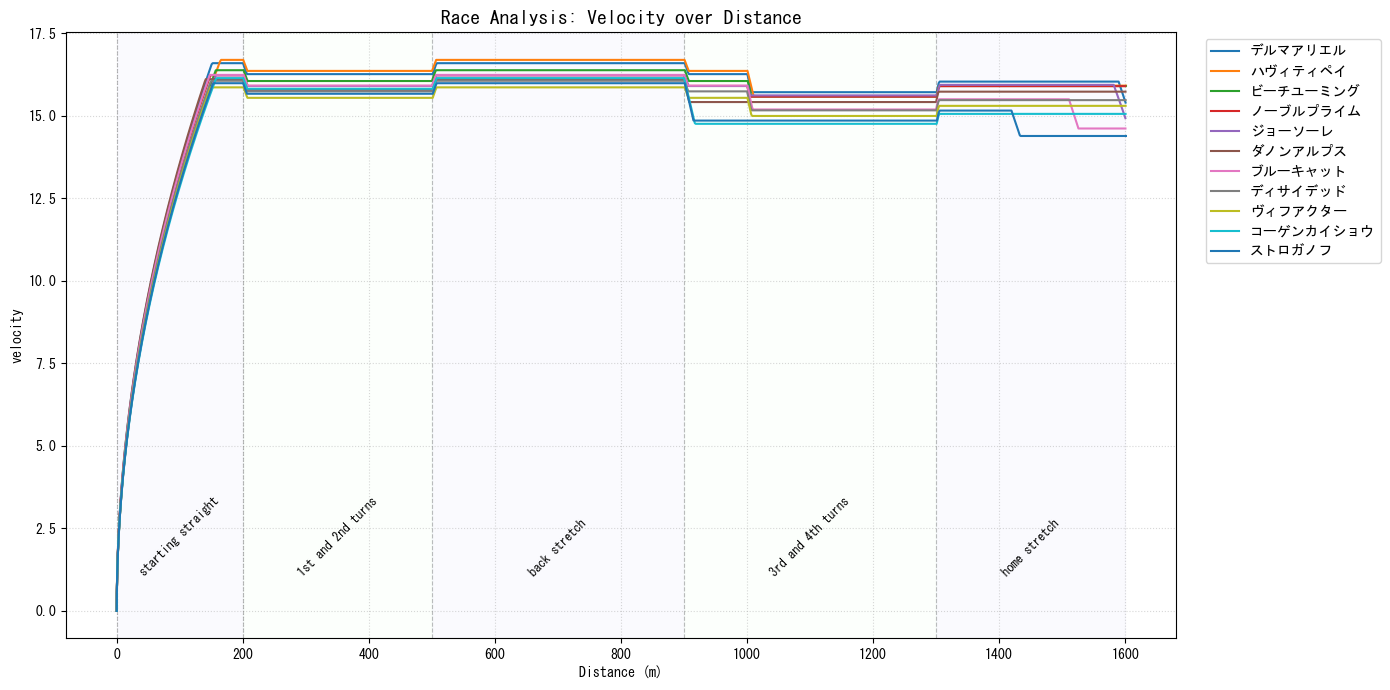

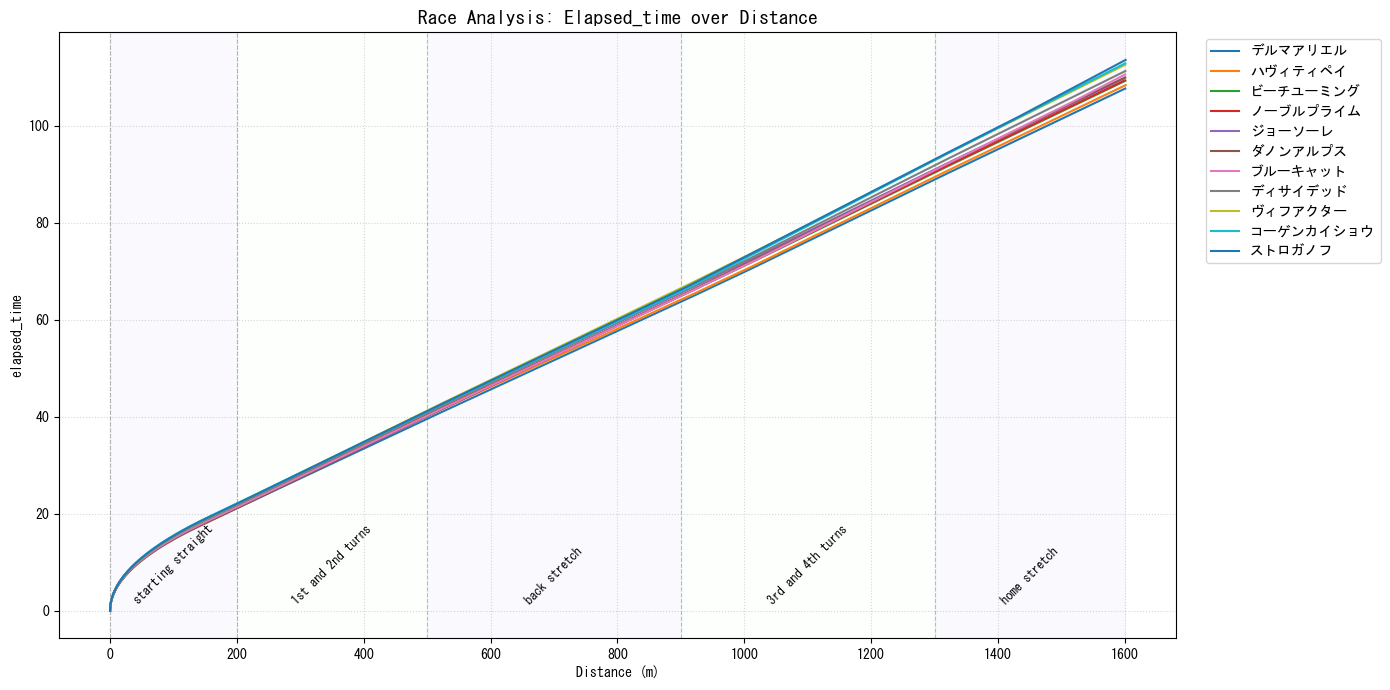

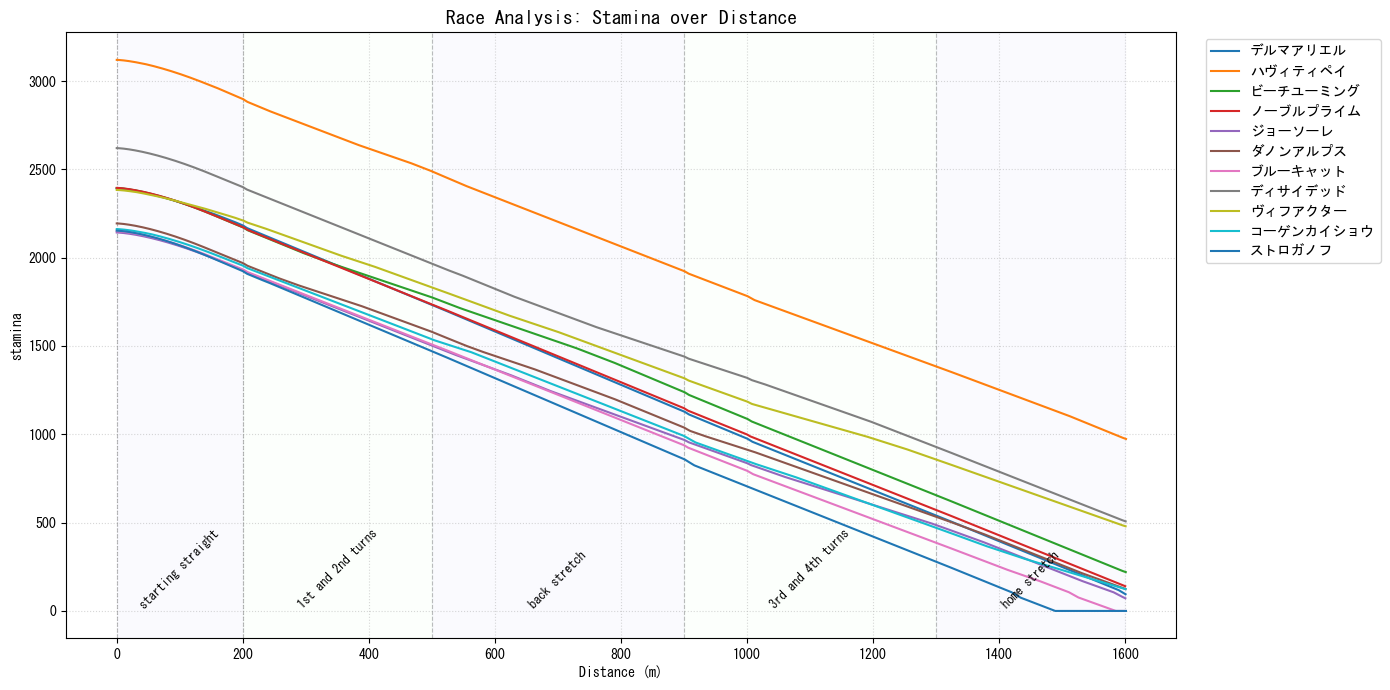

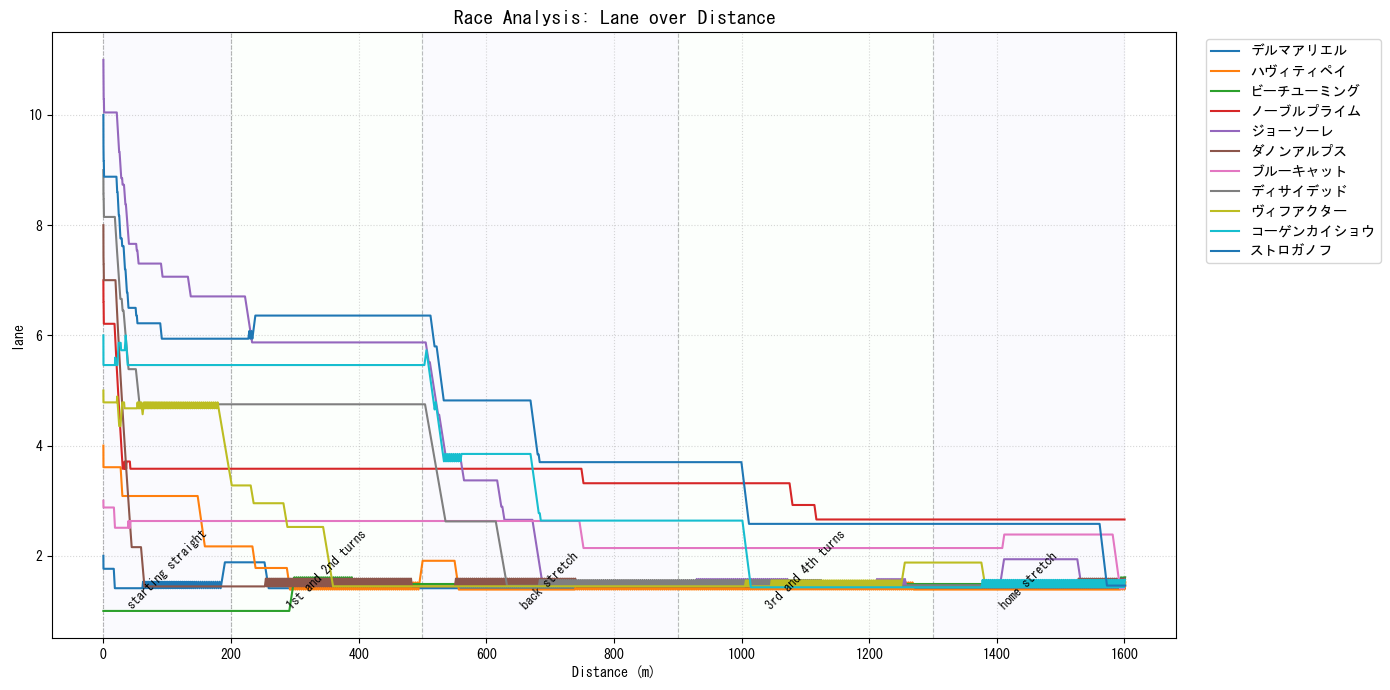

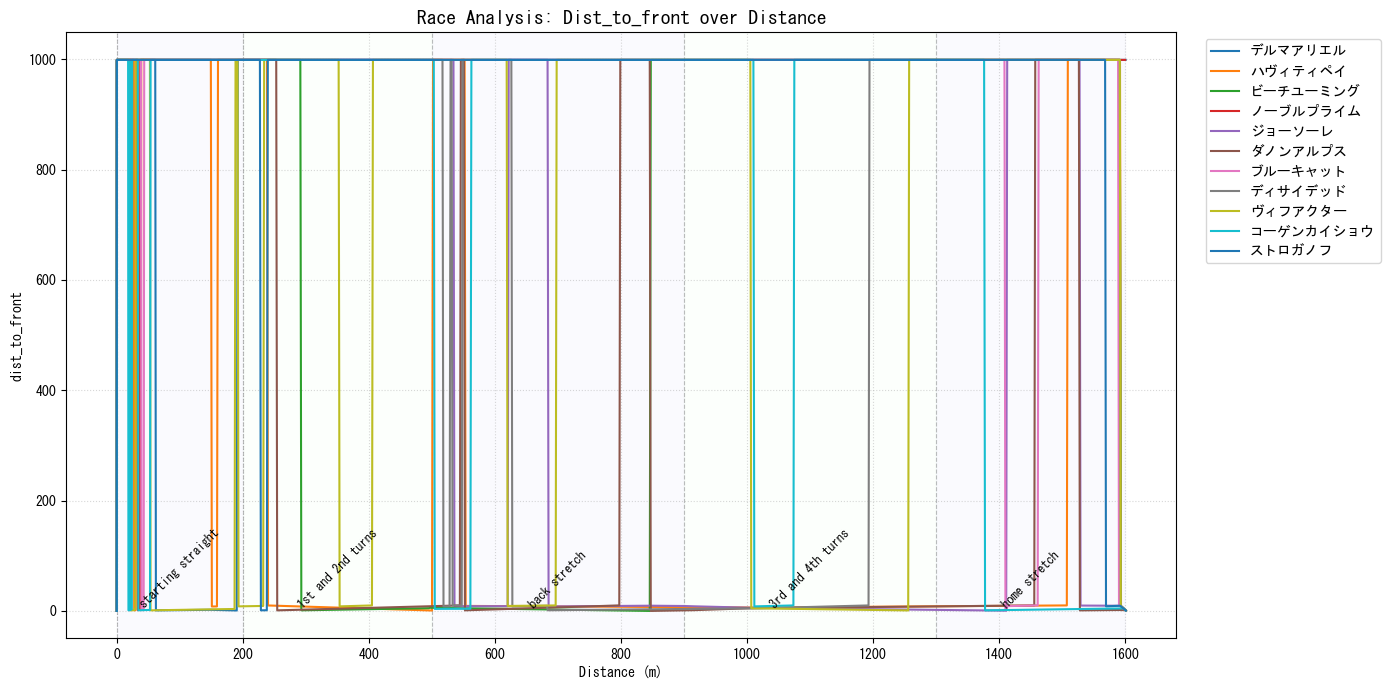

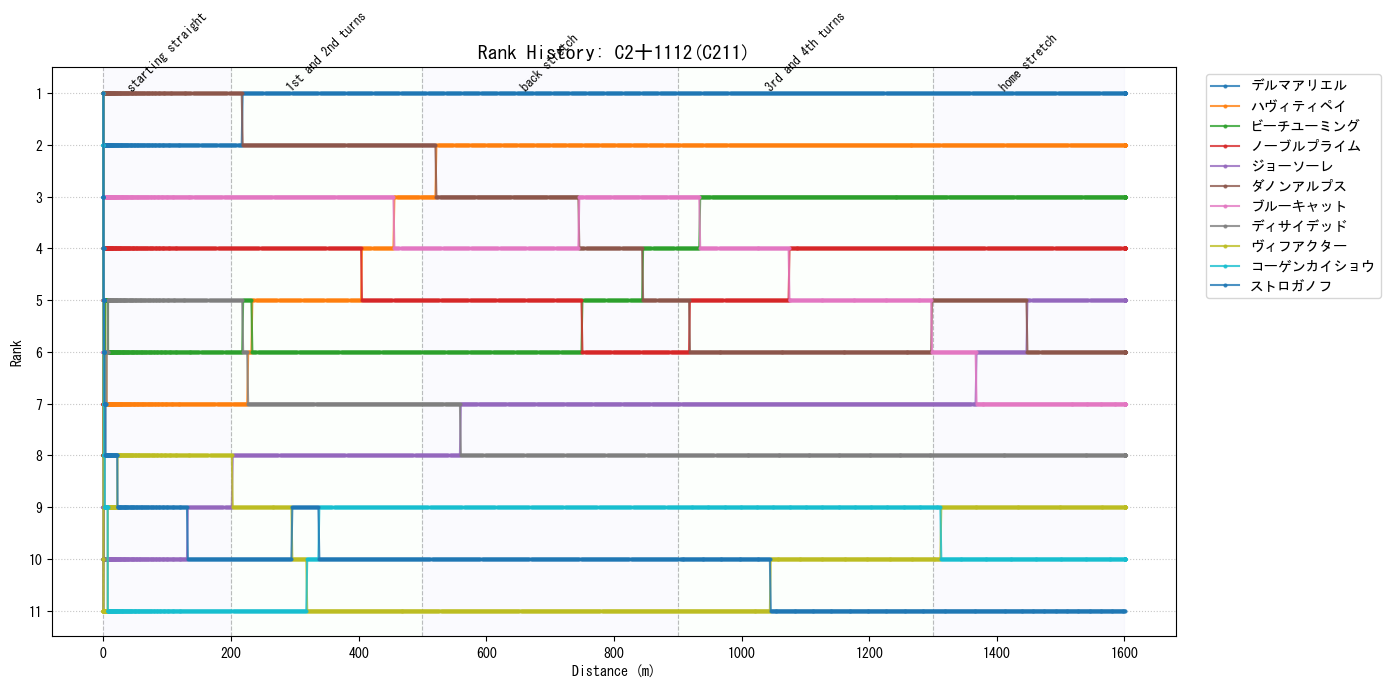

In [25]:
# プロット描写
from src.services.research_helper import RaceResultPlotter

plotter = RaceResultPlotter(race_info.profile, history)

plotter.plot_race_analysis(history, race_info.profile, "velocity")
plotter.plot_race_analysis(history, race_info.profile, "elapsed_time")
plotter.plot_race_analysis(history, race_info.profile, "stamina")
plotter.plot_race_analysis(history, race_info.profile, "lane")
plotter.plot_race_analysis(history, race_info.profile, "dist_to_front")
plotter.plot_race_rank_history(history, race_info.profile)

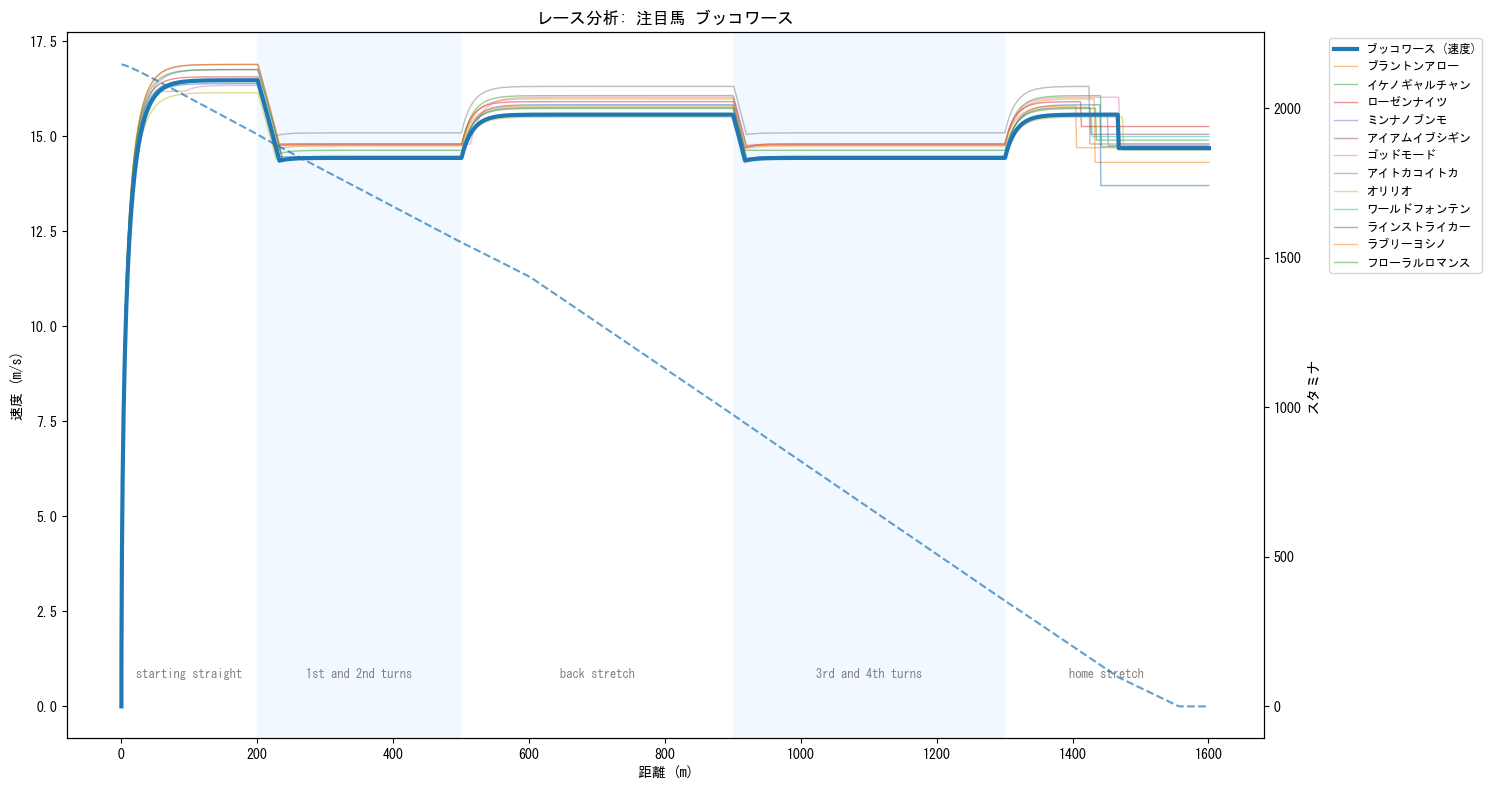

In [28]:
import matplotlib.pyplot as plt
import matplotlib
from src.models.race_data import RaceSnapshot, RaceProfile
from src.constants.enums import SectionType

# --- 日本語フォントの設定 ---
# 環境に合わせてフォントを選択してください
# Windows: 'MS Gothic', Mac: 'AppleGothic' or 'Hiragino Sans GB', Linux: 'Japan00' など
matplotlib.rcParams['font.family'] = 'MS Gothic' # Windowsの場合の例

def plot_race_analysis_names(history: list[RaceSnapshot], race_profile: RaceProfile, target_horse_id=None):
    """
    IDの代わりに馬名を表示し、全頭の速度と特定馬のスタミナを可視化
    """
    plt.figure(figsize=(15, 8))
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # IDから名前を引くための辞書を作成
    id_to_name = {h_id: h_prof.name for h_id, h_prof in race_profile.horses.items()}
    
    all_horse_ids = list(history[0].horses.keys())
    
    if target_horse_id is None:
        target_id_str = str(all_horse_ids[0])
    else:
        target_id_str = str(target_horse_id)

    # 1. セクション背景（前回と同様）
    color_map = {SectionType.STRAIGHT: "#ffffff", SectionType.CURVE: "#f2f8ff"}
    for section in race_profile.sections:
        start, end = section.start_at, section.start_at + section.distance
        ax1.axvspan(start, end, color=color_map.get(section.type, "#ffffff"), alpha=1.0, zorder=0)
        label_text = section.name.value if hasattr(section.name, 'value') else str(section.name)
        ax1.text((start + end) / 2, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 18, 
                 label_text, ha='center', va='top', fontsize=9, color='gray')

    # 2. 全馬のプロット
    for h_id in all_horse_ids:
        h_id_str = str(h_id)
        h_name = id_to_name.get(int(h_id_str), h_id_str) # 名前がなければIDを表示
        
        distances, velocities, staminas = [], [], []
        for snapshot in history:
            h_s = snapshot.horses.get(h_id)
            if h_s:
                distances.append(h_s.distance); velocities.append(h_s.velocity); staminas.append(h_s.stamina)

        if h_id_str == target_id_str:
            line, = ax1.plot(distances, velocities, label=f"{h_name} (速度)", linewidth=3, zorder=5)
            ax2.plot(distances, staminas, color=line.get_color(), linestyle='--', alpha=0.7, label=f"{h_name} (スタミナ)", zorder=4)
        else:
            ax1.plot(distances, velocities, label=h_name, linewidth=1, alpha=0.5, zorder=3)

    ax1.set_xlabel('距離 (m)')
    ax1.set_ylabel('速度 (m/s)')
    ax2.set_ylabel('スタミナ')
    plt.title(f"レース分析: 注目馬 {id_to_name.get(int(target_id_str), target_id_str)}")
    
    ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')
    plt.tight_layout()
    plt.show()

plot_race_analysis_names(history, race_profile)

INFO: root: id: 2021103462
INFO: root: id: 2021104202
INFO: root: id: 2019101304
INFO: root: id: 2021102429
INFO: root: id: 2019109083
INFO: root: id: 2021102897
INFO: root: id: 2019101552
INFO: root: id: 2022109083
INFO: root: id: 2021106391
INFO: root: id: 2020106112
INFO: root: id: 2019102067
INFO: root: id: 2020102455


INFO: root: id: 2019109031


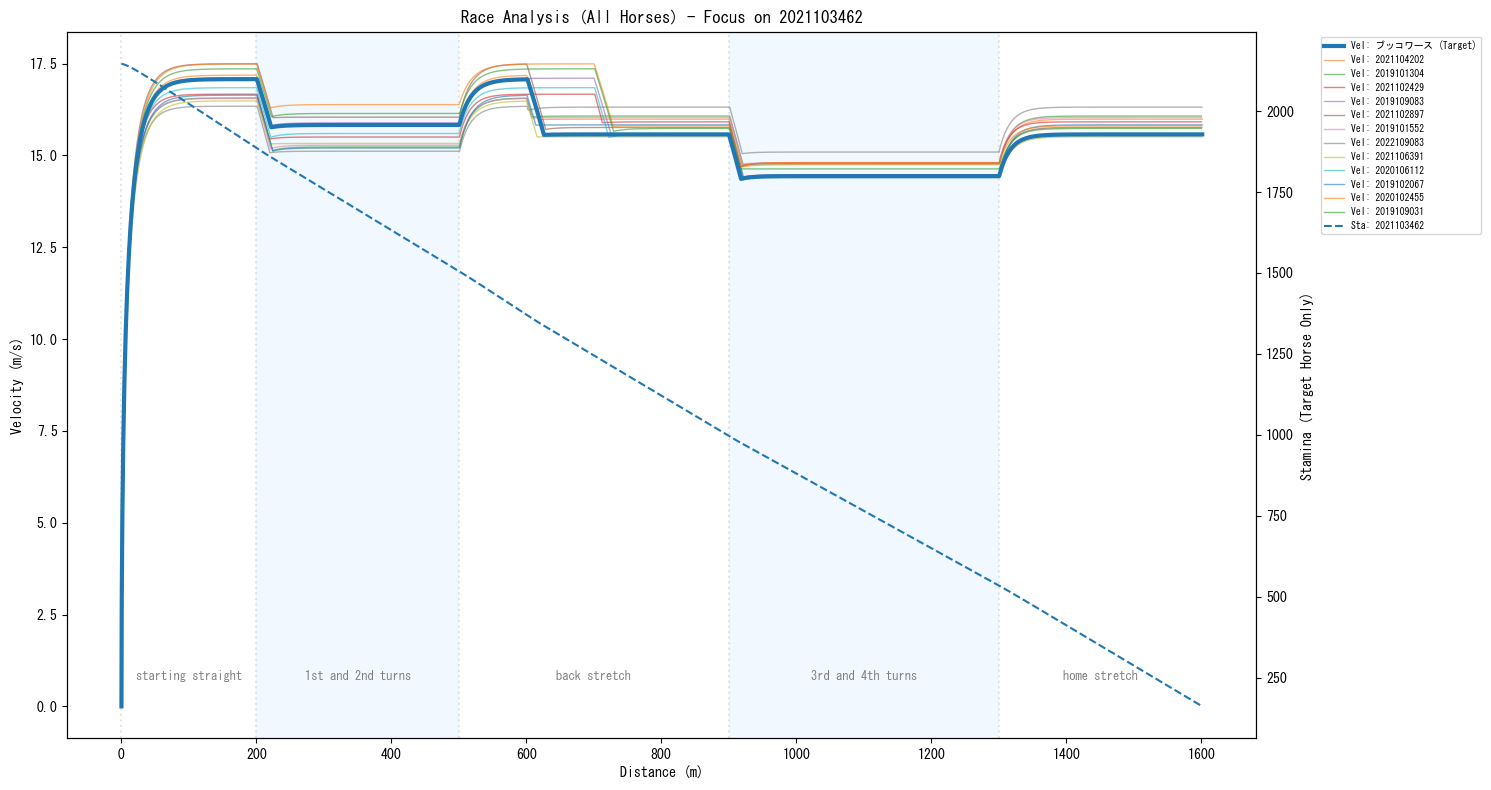

In [16]:
import matplotlib.pyplot as plt
from src.models.race_data import RaceSnapshot, RaceProfile
from src.constants.enums import SectionType

def plot_race_analysis_full(history: list[RaceSnapshot], race_profile: RaceProfile, target_horse_id=None):
    """
    全馬の速度をプロットしつつ、セクション情報と特定馬のスタミナを表示する
    """
    plt.figure(figsize=(15, 8))
    ax1 = plt.gca() # 速度用（左軸）
    ax2 = ax1.twinx() # スタミナ用（右軸）

    # 馬の名前辞書を取得
    horse_names = {}
    for h_id, h_p in race_profile.horses.items():
        logger.info(f"id: {h_id}")
        horse_names[h_id] = h_p.name

    # すべての馬のIDを取得
    all_horse_ids = list(history[0].horses.keys())
    
    # target_horse_idが未指定なら、リストの先頭の馬をスタミナ表示対象にする
    if target_horse_id is None:
        target_id_str = str(all_horse_ids[0])
    else:
        target_id_str = str(target_horse_id)

    # 1. セクション背景の描画 (SectionType, SectionNameを使用)
    color_map = {
        SectionType.STRAIGHT: "#ffffff", # 直線：白
        SectionType.CURVE: "#f2f8ff",    # コーナー：極薄い青
    }

    for section in race_profile.sections:
        start = section.start_at
        end = section.start_at + section.distance
        bg_color = color_map.get(section.type, "#ffffff")
        ax1.axvspan(start, end, color=bg_color, alpha=1.0, zorder=0)
        ax1.axvline(x=start, color='gray', linestyle=':', alpha=0.2, zorder=1)
        
        # セクション名の表示
        label_text = section.name.value if hasattr(section.name, 'value') else str(section.name)
        ax1.text((start + end) / 2, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 18, 
                 label_text, ha='center', va='top', fontsize=9, color='gray', zorder=1)

    # 2. 全馬のデータをプロット
    for h_id in all_horse_ids:
        h_id_str = str(h_id)
        distances = []
        velocities = []
        staminas = []

        for snapshot in history:
            h_s = snapshot.horses.get(h_id)
            if h_s:
                distances.append(h_s.distance)
                velocities.append(h_s.velocity)
                staminas.append(h_s.stamina)

        if not distances:
            continue

        # 特定の馬(target)かそれ以外かで見た目を変える
        if h_id_str == target_id_str:
            # 指定馬：太い線で速度を描画 ＋ スタミナを右軸に描画
            line, = ax1.plot(distances, velocities, label=f"Vel: {horse_names[int(h_id_str)]} (Target)", linewidth=3, zorder=5)
            ax2.plot(distances, staminas, color=line.get_color(), linestyle='--', linewidth=1.5, label=f"Sta: {h_id_str}", zorder=4)
        else:
            # 他の馬：細い線で速度のみ描画
            ax1.plot(distances, velocities, label=f"Vel: {h_id_str}", linewidth=1, alpha=0.6, zorder=3)

    # 3. グラフの装飾
    ax1.set_xlabel('Distance (m)')
    ax1.set_ylabel('Velocity (m/s)')
    ax2.set_ylabel('Stamina (Target Horse Only)')
    
    plt.title(f"Race Analysis (All Horses) - Focus on {target_id_str}")
    
    # 凡例を外側に配置（頭数が多い場合に対応）
    handler1, label1 = ax1.get_legend_handles_labels()
    handler2, label2 = ax2.get_legend_handles_labels()
    ax1.legend(handler1 + handler2, label1 + label2, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='x-small')

    plt.tight_layout()
    plt.show()

# 実行例
plot_race_analysis_full(history, race_profile)

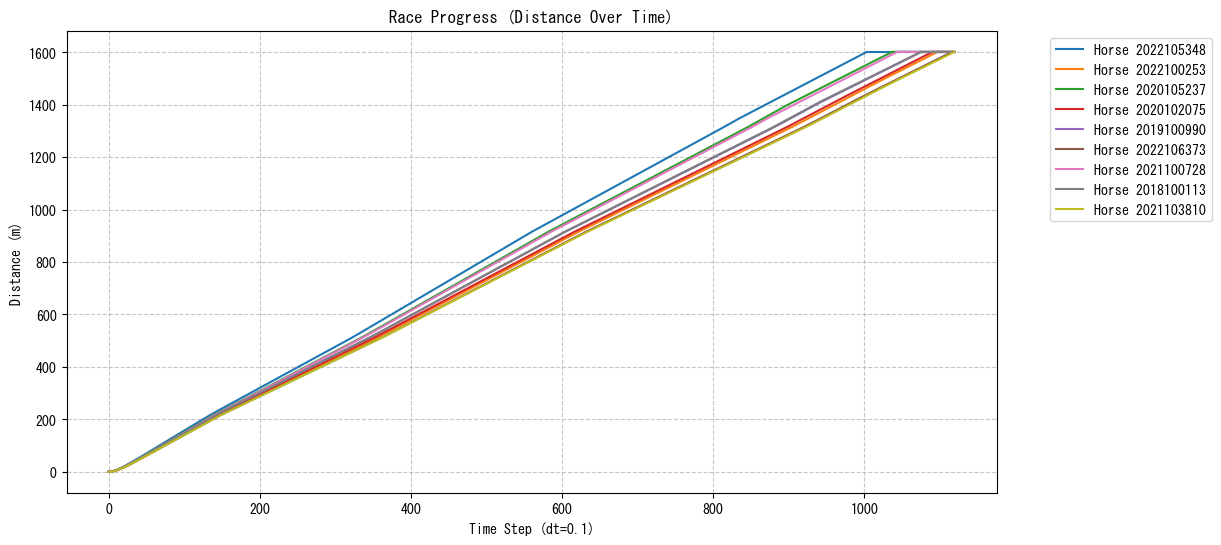

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from src.models.race_data import RaceSnapshot

def plot_race_results(history: list[RaceSnapshot]):
    # 1. 履歴リストを、Pandasが扱いやすい「辞書のリスト」に変換
    data_log = []
    for snapshot in history:
        # 各ステップのデータを抽出
        row = {h_id: h_s.distance for h_id, h_s in snapshot.horses.items()}
        row['step'] = snapshot.step
        data_log.append(row)

    # 2. DataFrameを作成し、stepをインデックス（横軸）にする
    df = pd.DataFrame(data_log).set_index('step')

    # 3. グラフの描画
    plt.figure(figsize=(12, 6))
    for horse_id in df.columns:
        plt.plot(df.index, df[horse_id], label=f"Horse {horse_id}")

    plt.title("Race Progress (Distance Over Time)")
    plt.xlabel("Time Step (dt=0.1)")
    plt.ylabel("Distance (m)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 凡例を外側に
    plt.show()

# 実行
plot_race_results(history)

In [ ]:
# デバッグテスト用
from src.simulator import RaceSimulator
from src.services.factory import DebugRaceFactory, DebugHorseFactory

sim = RaceSimulator(DebugRaceFactory())

info_list = [sim.factory.create_race()]
horses = {}
for i in range(0, 8):
    h_prof = sim.factory.horse_factory.create_horse_profile_as_random()
    horses[h_prof.horse_id] = h_prof
new_info = sim.factory.entry_horses(info_list[0], horses)
for h in new_info.profile.horses.values():
    logger.info(h)
for h in new_info.snapshot.horses.values():
    logger.info(h)

INFO: src.simulator: 初期化中...
INFO: src.core.engine: 初期化中...
INFO: root: HorseProfile(horse_id='D000000001', name='ダミー馬01', bracket_num=1, horse_num=2, jockey='ダミー機種01', horse_weight=514.6543883987812, weight_carried=56.0, max_speed=16.850225591977466, min_speed=14.47684908098593, acceleration=1.0232115038936442, total_stamina=2110.420478899461, stamina_waste_rate=0.9595513150058157, cornering_ability=0.4512152933019625, gate_reaction=0.7878876459887882, strategy='closer', target_spurt_dist=571.0122956855778)
INFO: root: HorseProfile(horse_id='D000000002', name='ダミー馬02', bracket_num=1, horse_num=3, jockey='ダミー機種02', horse_weight=364.4693272958506, weight_carried=55.0, max_speed=15.689049778308732, min_speed=14.097699932402149, acceleration=1.1740312806203388, total_stamina=2245.5433612616257, stamina_waste_rate=1.0138464361719823, cornering_ability=0.5887485173479173, gate_reaction=0.7129652819696144, strategy='rear', target_spurt_dist=665.3855574257371)
INFO: root: HorseProfile(horse_i